/tmp/ipykernel_5209/4134911536.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


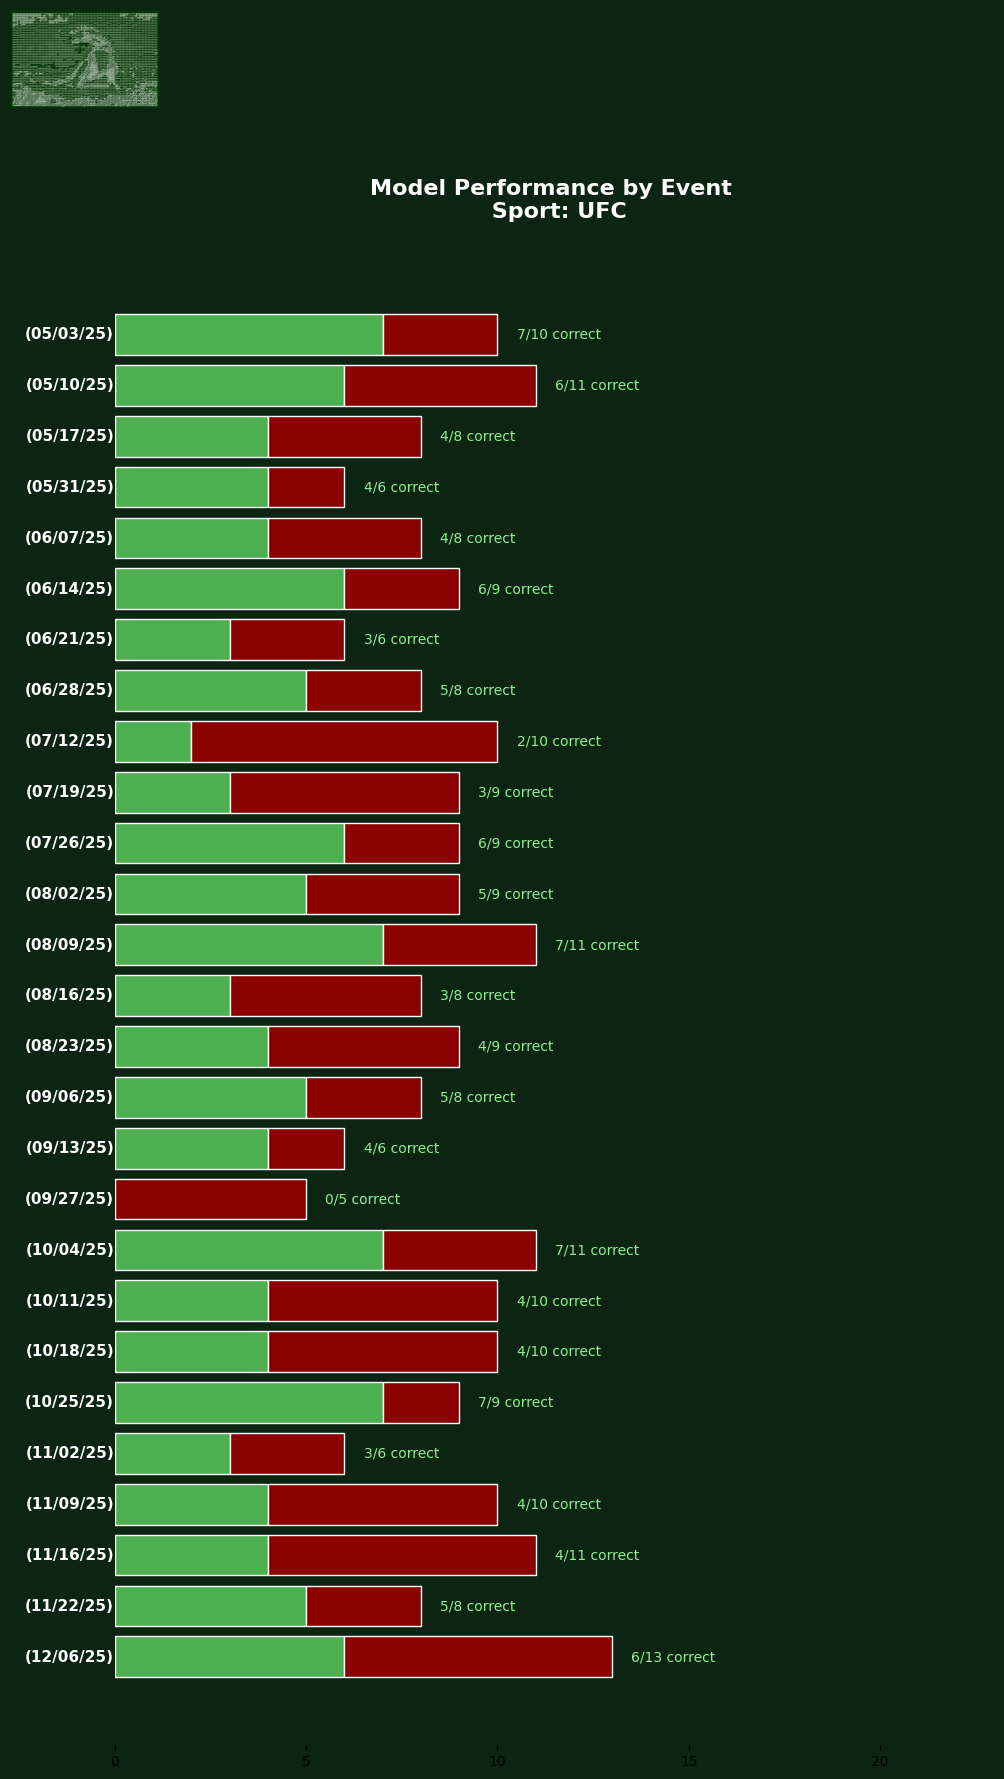

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def open_image_local(path_to_image):
    image = Image.open(path_to_image)
    image_array = np.array(image)
    return image_array

logo = open_image_local("/home/robs/Downloads/ASCIITREX.png")
image_xaxis = 0
image_yaxis = .99
image_width = 0.15
image_height = 0.15
summary_df1=pd.read_csv("/home/robs/MMA_Outcomes/Model_Outcomes.csv")

summary_df1 = summary_df1.sort_values('Event Date', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 0.6 * len(summary_df1)))
fig.patch.set_facecolor('#0b2512')
ax.set_facecolor('#0b2512')

# Plot each stacked bar
for i, row in summary_df1.iterrows():
    ax.barh(i, row['Correct'], color='#4CAF50', edgecolor='white')  # green for correct
    ax.barh(i, row['Wrong'], left=row['Correct'], color='#8B0000', edgecolor='white')  # red for wrong

    # Add text labels
    ax.text(row['Total'] + 0.5, i, f"{row['Correct']}/{row['Total']} correct",
            va='center', ha='left', color='lightgreen', fontsize=10)

    ax.text(-0.02, i, f"({row['Event Date']})",
            va='center', ha='right', fontsize=11, color='white', fontweight='bold')

# Formatting
ax.set_yticks([])
ax.set_xlim(0, summary_df1['Total'].max() + 10)
ax.set_title("Model Performance by Event \n Sport: UFC",
             fontsize=16, color='white', pad=20, weight='bold')
ax_image = fig.add_axes([
                        image_xaxis,
                         image_yaxis,
                         image_width,
                         image_height
])
for spine in ax.spines.values():
    spine.set_visible(False)
ax_image.imshow(logo)
ax_image.axis('off')
plt.tight_layout()
plt.savefig("correct_vs_wrong_predictions.png", format='png', dpi=300, bbox_inches='tight')
plt.show()
